# STC Jawwy

In [5]:
"""
Here we install libraries that are not installed by default
Example:  pyslsb
Feel free to add any library you are planning to use.
"""
!pip install pyxlsb

In [6]:
# Import the required libraries
"""
Please feel free to import any required libraries as per your needs
"""
import pandas as pd     # provides high-performance, easy to use structures and data analysis tools
import pyxlsb           # Excel extention to read xlsb files (the input file)
import numpy as np      # provides fast mathematical computation on arrays and matrices

# Jawwy dataset
The dataset includes total watching hours for customers per day.

You are required to work on predecting the forecast for the watching hours.

In [7]:
dataframe = pd.read_excel("/content/stc TV Data Set_T2.xlsx",index_col=0)
# Please make a copy of dataset if you are going to work directly and make changes on the dataset
# you can use   df=dataframe.copy()
df=dataframe.copy()

In [8]:
# check the data shape
dataframe.shape

(86, 2)

In [9]:
# display the first 5 rows
dataframe.head()

,date_,Total_watch_time_in_houres
0,2018-01-01,1123.551944
1,2018-01-02,1000.129722
2,2018-01-03,881.924444
3,2018-01-04,782.669444
4,2018-01-05,1051.939444


In [10]:
# display the dataset after applying data types
dataframe.head()

,date_,Total_watch_time_in_houres
0,2018-01-01,1123.551944
1,2018-01-02,1000.129722
2,2018-01-03,881.924444
3,2018-01-04,782.669444
4,2018-01-05,1051.939444


In [11]:
# describe the numeric values in the dataset
dataframe.describe()

,date_,Total_watch_time_in_houres
count,86,86.000000
mean,2018-02-28 17:01:23.720930304,780.817926
min,2018-01-01 00:00:00,562.124722
25%,2018-01-30 06:00:00,707.709653
50%,2018-02-28 12:00:00,763.181389
75%,2018-03-29 18:00:00,840.985278
max,2018-04-30 00:00:00,1123.551944
std,NaN,122.992002


In [12]:
# check if any column has null value in the dataset
dataframe.isnull().any()

,0
date_,False
Total_watch_time_in_houres,False


In [13]:
# we import Visualization libraries
# you can ignore and use any other graphing libraries
import matplotlib.pyplot as plt # a comprehensive library for creating static, animated, and interactive visualizations
import plotly #a graphing library makes interactive, publication-quality graphs. Examples of how to make line plots, scatter plots, area charts, bar charts, error bars, box plots, histograms, heatmaps, subplots, multiple-axes, polar charts, and bubble charts.
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [14]:
# Setting the date as index
dataframe.set_index('date_', inplace=True)

In [15]:
# Display the dataframe after setting the date as index
dataframe.head()

,Total_watch_time_in_houres
date_,
2018-01-01,1123.551944
2018-01-02,1000.129722
2018-01-03,881.924444
2018-01-04,782.669444
2018-01-05,1051.939444


In [16]:
# show the dataframe
fig = px.line(dataframe,  y="Total_watch_time_in_houres")
fig.show()

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 2.


Expected Watch Time for the Next Two Months:
          ds          yhat    yhat_lower    yhat_upper
4 2018-05-31  12429.314358  11512.356892  13356.444404
5 2018-06-30  10709.057346   9804.314190  11699.402145


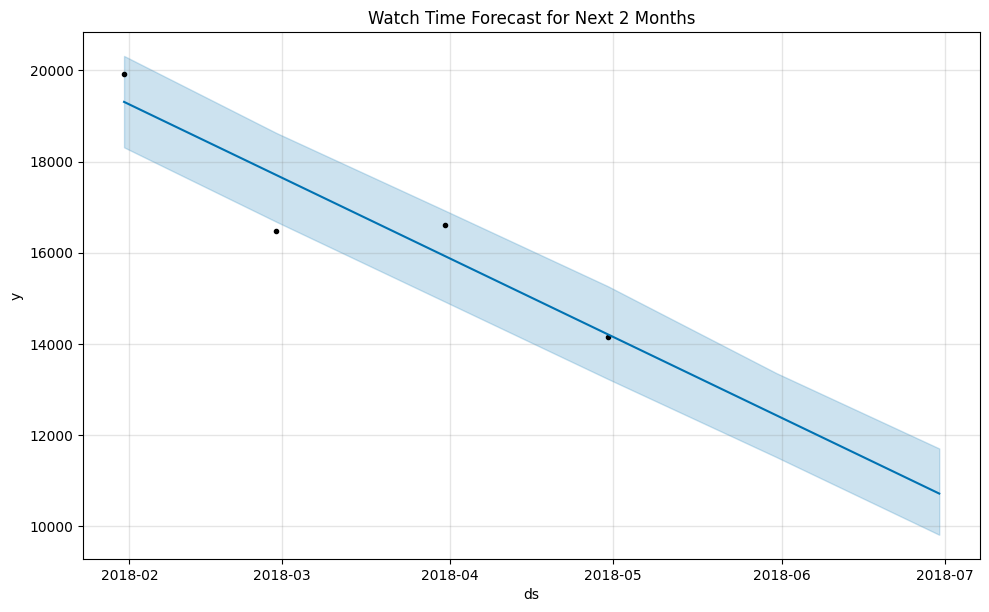

In [17]:
# Install Prophet if needed
# !pip install prophet

import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

# Convert date column to datetime
df['date_'] = pd.to_datetime(df['date_'])

# Aggregate watch time by month
monthly_watch = (
    df.groupby(pd.Grouper(key='date_', freq='ME'))['Total_watch_time_in_houres']
      .sum()
      .reset_index()
)

# Rename columns for Prophet
monthly_watch.columns = ['ds', 'y']

# Build and train forecasting model
model = Prophet()
model.fit(monthly_watch)

# Forecast next 2 months
future = model.make_future_dataframe(periods=2, freq='ME')
forecast = model.predict(future)

# Display forecasted watch time for next 2 months
next_2_months = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(2)

print("Expected Watch Time for the Next Two Months:")
print(next_2_months)

# Plot forecast
fig = model.plot(forecast)
plt.title('Watch Time Forecast for Next 2 Months')
plt.show()

In [18]:
# التأكد من أن التاريخ بصيغة datetime
df['date_'] = pd.to_datetime(df['date_'])

# عرض بيانات 28 مارس 2018
watch_28_mar = df[df['date_'] == '2018-03-28']

print(watch_28_mar)

        date_  Total_watch_time_in_houres
62 2018-03-28                  562.124722
